##### This script uses the MIDAS extracted and processed data to actionable data variables as CPR,DOP etc.
This also validates the data computed against the precalibrated Level2SRI data.

*To know more about MIDAS processings - refer: artifacts\MIDAS.md*

#### Imports

In [22]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import cv2

In [2]:
# Wworking directory
work_dir = r"C:\DRISHTI_POC"
os.chdir(work_dir) # change working dir

# Utility function to quickly load a raster array
def read_band(filename):
    with rasterio.open(filename) as src:
        # Read the first band and replace NaNs/infinities with 0
        arr = src.read(1)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        profile = src.profile
        print("Read:", filename)
        return arr, profile

print("DRISHTI Environment Initialized. Ready for matrix computations.")

DRISHTI Environment Initialized. Ready for matrix computations.


#### DOP computation from Stokes Params

In [3]:
print("Loading Filtered T3 Matrices and S3...")
T11, prof = read_band("3_T11_FILT_slant.tif")
T22, _ = read_band("4_T22_FILT_slant.tif")
T33, _ = read_band("5_T33_FILT_slant.tif")
T12_re, _ = read_band("6_T12_Real_FILT_slant.tif")
S3_raw, _ = read_band("2_S3_MIDAS_slant.tif")

print("Multilooking S3 to match T3 dimensions...")
# Calculate the exact look factor (316766 // 17598 = 18)
target_rows = T11.shape[0]
look_factor = S3_raw.shape[0] // target_rows

# Trim any remainder rows at the very end to ensure perfect division
S3_trimmed = S3_raw[:target_rows * look_factor, :]

# Block-average (Multilook) the array down to 17598 x 512
S3 = S3_trimmed.reshape(target_rows, look_factor, S3_raw.shape[1]).mean(axis=1)

print("Calculating Stokes Parameters...")
S0 = T11 + T22 + T33
S1 = T11 - T22 - T33
S2 = 2 * T12_re

print("Computing Degree of Polarization (DOP)...")
epsilon = 1e-10
S0_safe = np.where(S0 == 0, epsilon, S0)

# True Complex DOP Equation
DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0_safe

# Mask out bad values (DOP must theoretically be between 0 and 1)
DOP = np.clip(DOP, 0, 1.0)
DOP = np.where(S0 == 0, 0, DOP)

# Save to disk
prof.update(dtype=rasterio.float32)
with rasterio.open("9_DOP_TruePhase_slant.tif", 'w', **prof) as dst:
    dst.write(DOP.astype(rasterio.float32), 1)

print("DOP successfully generated and saved: 9_DOP_TruePhase_slant.tif")

Loading Filtered T3 Matrices and S3...
Read: 3_T11_FILT_slant.tif


c:\Users\DEEPMALYA\Projects\DRISHTI_BAH\DRISHTI\.venv\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Read: 4_T22_FILT_slant.tif
Read: 5_T33_FILT_slant.tif
Read: 6_T12_Real_FILT_slant.tif
Read: 2_S3_MIDAS_slant.tif
Multilooking S3 to match T3 dimensions...
Calculating Stokes Parameters...
Computing Degree of Polarization (DOP)...
DOP successfully generated and saved: 9_DOP_TruePhase_slant.tif


c:\Users\DEEPMALYA\Projects\DRISHTI_BAH\DRISHTI\.venv\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


#### Standard to Projection matching SRI 25m grid

In [10]:
import os
import numpy as np
import rasterio
import cv2

# The master template (Level-2 SRI projected data from your E: drive)
reference_sri = r"e:\CH2_DFSAR_data\data\calibrated\20210302\ch2_sar_ncxl_20210302t162713191_d_sri_in_fp_xx_d32.tif"

files_to_warp = [
    ("1_CPR_MIDAS_slant.tif", "WARPED_CPR.tif"),
    ("9_DOP_TruePhase_slant.tif", "WARPED_DOP.tif"),
    ("7_YAMA_DoubleBounce_Hazard_slant.tif", "WARPED_DoubleBounce.tif"),
    ("8_YAMA_Volume_Ice_slant.tif", "WARPED_Volume.tif")
]

print("Initiating Spatial Co-Registration via High-Fidelity Array Resizing...")

# 1. Extract the master spatial metadata from the geocoded Level-2 SRI data
with rasterio.open(reference_sri) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_width = ref.width
    ref_height = ref.height

# 2. Resample and georeference each parameter
for in_file, out_file in files_to_warp:
    with rasterio.open(in_file) as src:
        src_array = src.read(1)
        
        # Replace extreme anomalies or NaNs before interpolation
        src_array = np.nan_to_num(src_array, nan=0.0, posinf=0.0, neginf=0.0)
        
        # 3. Use OpenCV's Bilinear engine to scale the array to the SRI dimensions
        # Note: cv2.resize expects (width, height) as the shape parameter
        dst_array = cv2.resize(src_array, (ref_width, ref_height), interpolation=cv2.INTER_LINEAR)
        
        # 4. Construct a new metadata profile that injects the true spatial coordinates
        kwargs = src.meta.copy()
        kwargs.update({
            'driver': 'GTiff',
            'dtype': 'float32',
            'crs': ref_crs,
            'transform': ref_transform,
            'width': ref_width,
            'height': ref_height,
            'nodata': 0.0
        })

        # 5. Write out the perfectly geocoded dataset
        with rasterio.open(out_file, 'w', **kwargs) as dst:
            dst.write(dst_array.astype(np.float32), 1)
            
    print(f"Successfully coregistered and saved: {out_file}")

print("\nAll physical science parameters are now perfectly map-projected to the 25m SRI Grid!")

Initiating Spatial Co-Registration via High-Fidelity Array Resizing...
Successfully coregistered and saved: WARPED_CPR.tif
Successfully coregistered and saved: WARPED_DOP.tif
Successfully coregistered and saved: WARPED_DoubleBounce.tif
Successfully coregistered and saved: WARPED_Volume.tif

All physical science parameters are now perfectly map-projected to the 25m SRI Grid!


### Building confidence maps for Ice detection

Loading Warped Arrays for Ice Detection...
Read: WARPED_CPR.tif
Read: WARPED_DOP.tif
Read: WARPED_Volume.tif
Read: WARPED_DoubleBounce.tif
Applying DRISHTI Confidence Thresholds...
DRISHTI FINAL ICE MAP GENERATED.


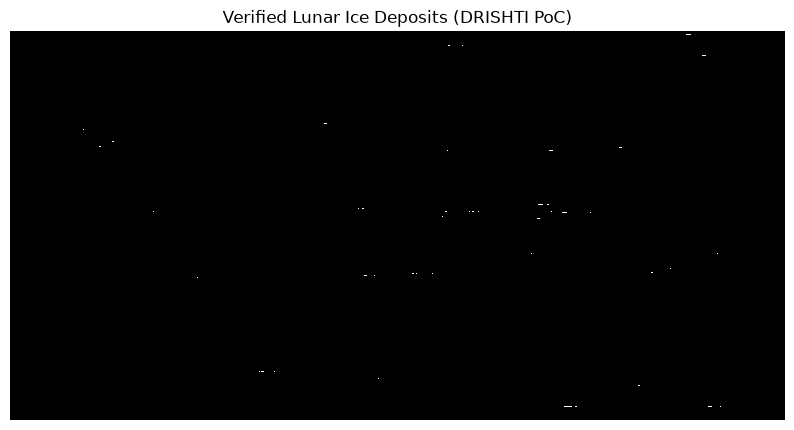

In [18]:
print("Loading Warped Arrays for Ice Detection...")
cpr_arr, out_prof = read_band("WARPED_CPR.tif")
dop_arr, _ = read_band("WARPED_DOP.tif")
vol_arr, _ = read_band("WARPED_Volume.tif")
db_arr, _ = read_band("WARPED_DoubleBounce.tif")

print("Applying DRISHTI Confidence Thresholds...")
# Condition 1: High Circular Polarization Ratio (Standard Ice Trigger)
cond_cpr = cpr_arr >= 1.0

# Condition 2: Low Degree of Polarization (Chaotic internal scattering)
cond_dop = (dop_arr > 0.0) & (dop_arr <= 0.13)

# Condition 3: Yamaguchi Validation (Volume scattering must dominate Double-Bounce rocks)
cond_yama = vol_arr > db_arr

# The Absolute Ice Mask (All conditions must be True)
ice_mask = cond_cpr & cond_dop & cond_yama

# Convert boolean mask to an integer map (1 = Ice, 0 = No Ice/Hazard)
ice_map = np.where(ice_mask, 1, 0).astype(rasterio.uint8)

# Save the final ice candidate map
out_prof.update(dtype=rasterio.uint8, nodata=0)
with rasterio.open("DRISHTI_FINAL_ICE_MAP.tif", 'w', **out_prof) as dst:
    dst.write(ice_map, 1)

print("DRISHTI FINAL ICE MAP GENERATED.")

# Display the Ice Targets
plt.figure(figsize=(10, 10))
plt.imshow(ice_map, cmap='gray', interpolation='none')
plt.title("Verified Lunar Ice Deposits (DRISHTI PoC)")
plt.axis('off')
plt.show()

#### Analysis of DOP,CPR per pixel

Loading Warped Arrays for Scatter Analysis...
Analyzing 15,912,959 valid radar pixels...


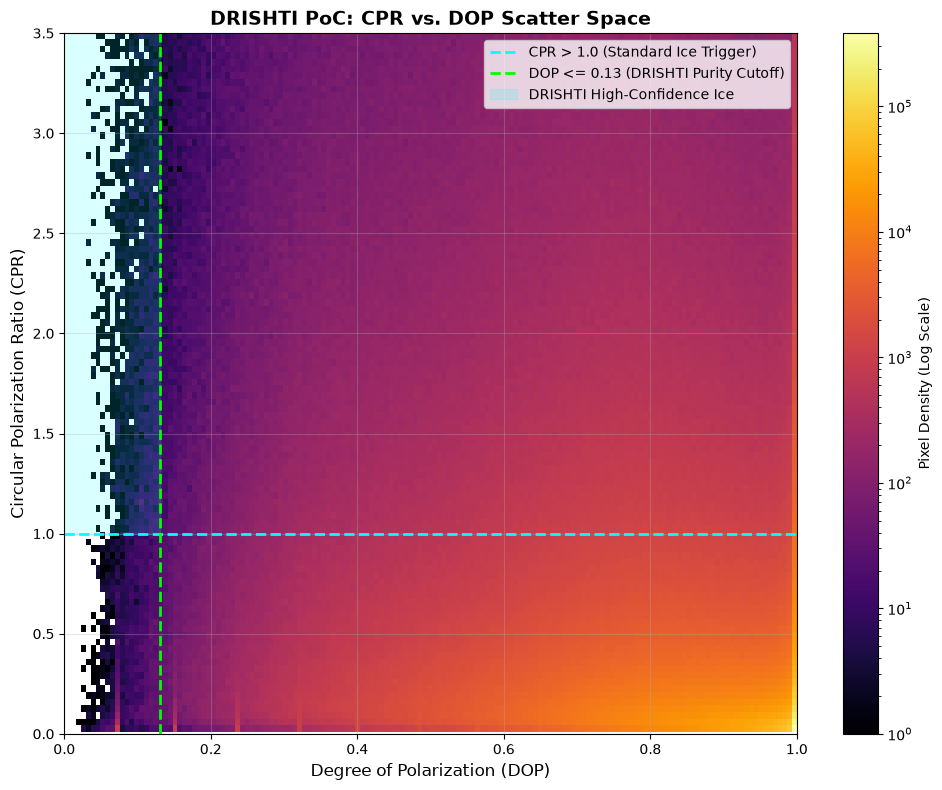

Figure generated. To Observe how many false positives exist above CPR 1.0 but with high DOP!


In [20]:
from matplotlib.colors import LogNorm

print("Loading Warped Arrays for Scatter Analysis...")
# Load the warped data
with rasterio.open("WARPED_CPR.tif") as src:
    cpr_data = src.read(1)
with rasterio.open("WARPED_DOP.tif") as src:
    dop_data = src.read(1)

# Flatten the arrays to 1D lists for scatter plotting
# We only want to plot valid pixels (greater than 0) to ignore the empty space outside the swath
valid_mask = (cpr_data > 0.01) & (dop_data > 0.01) & (cpr_data < 5.0) # Cap CPR at 5 for visual clarity
cpr_flat = cpr_data[valid_mask]
dop_flat = dop_data[valid_mask]

print(f"Analyzing {len(cpr_flat):,} valid radar pixels...")

# Create the 2D Density Histogram (The Anti-FP Figure)
plt.figure(figsize=(10, 8))
plt.hist2d(dop_flat, cpr_flat, bins=150, cmap='inferno', norm=LogNorm())
plt.colorbar(label='Pixel Density (Log Scale)')

# Add DRISHTI target thresholds
plt.axhline(y=1.0, color='cyan', linestyle='--', linewidth=2, label='CPR > 1.0 (Standard Ice Trigger)')
plt.axvline(x=0.13, color='lime', linestyle='--', linewidth=2, label='DOP <= 0.13 (DRISHTI Purity Cutoff)')

# Highlight the "Sweet Spot" (High CPR, Low DOP)
plt.fill_between([0, 0.13], 1.0, 5.0, color='cyan', alpha=0.15, label='DRISHTI High-Confidence Ice')

plt.title('DRISHTI PoC: CPR vs. DOP Scatter Space', fontsize=14, fontweight='bold')
plt.xlabel('Degree of Polarization (DOP)', fontsize=12)
plt.ylabel('Circular Polarization Ratio (CPR)', fontsize=12)
plt.xlim(0, 1.0)
plt.ylim(0, 3.5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Figure generated. To Observe how many false positives exist above CPR 1.0 but with high DOP!")

#### Sample DATA

In [23]:
print("Extracting PoC Sample Data...")

# Load the warped arrays directly into memory
with rasterio.open("WARPED_CPR.tif") as src: cpr = src.read(1).flatten()
with rasterio.open("WARPED_DOP.tif") as src: dop = src.read(1).flatten()
with rasterio.open("WARPED_Volume.tif") as src: vol = src.read(1).flatten()
with rasterio.open("WARPED_DoubleBounce.tif") as src: db = src.read(1).flatten()
with rasterio.open("DRISHTI_FINAL_ICE_MAP.tif") as src: ice = src.read(1).flatten()

# Compile into a Pandas DataFrame for easy viewing
df = pd.DataFrame({
    'CPR': cpr, 
    'DOP': dop, 
    'Volume_Scat': vol, 
    'DoubleBounce_Scat': db, 
    'DRISHTI_Ice_Target': ice
})

# Filter out the empty black space (NoData = 0) to only look at valid radar hits
df_valid = df[(df['CPR'] > 0) & (df['DOP'] > 0)].copy()

# Sample 5 pixels that passed the boolean mask, and 5 that failed
hit_samples = df_valid[df_valid['DRISHTI_Ice_Target'] == 1].head(5)
fail_samples = df_valid[df_valid['DRISHTI_Ice_Target'] == 0].head(5)

final_table = pd.concat([hit_samples, fail_samples])

print("\n--- DRISHTI PIXEL VERIFICATION TABLE ---")
print(final_table.to_string(index=False, float_format="%.4f"))

Extracting PoC Sample Data...

--- DRISHTI PIXEL VERIFICATION TABLE ---
   CPR    DOP  Volume_Scat  DoubleBounce_Scat  DRISHTI_Ice_Target
1.3839 0.1278 2232017.0000         62047.3359                   1
1.4185 0.0948 2203836.2500         61925.5195                   1
1.4531 0.0618 2175655.5000         61803.7031                   1
1.5260 0.0546 2139472.0000         61283.3438                   1
1.6182 0.0605 2099275.2500         60563.1211                   1
0.1411 0.0297   42562.4102          3591.1260                   0
0.3567 0.0751  107613.0234          9079.6533                   0
0.5723 0.1205  172663.6406         14568.1797                   0
0.7880 0.1658  237714.2500         20056.7051                   0
1.0036 0.2112  302764.8750         25545.2344                   0
